# EDA da Estacao Bangu

Este notebook sera usado para a analise exploratoria individual da **Estacao Bangu**. Nesta primeira etapa, vamos montar a **auditoria da base**, que serve para verificar se a serie da estacao e confiavel e em quais periodos ela apresenta melhor ou pior qualidade.

## Carregamento da base

Primeiro, carregamos a base consolidada de qualidade do ar e isolamos apenas os registros da estacao de Bangu. Como o nome da estacao pode vir com problema de codificacao, fazemos uma normalizacao simples para garantir um filtro robusto.

In [1]:
import pandas as pd
import unicodedata
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_air_quality["Nome_norm"] = df_air_quality["Nome"].map(lambda x: unicodedata.normalize("NFKD", str(x)).encode("ascii", "ignore").decode("utf-8").strip().upper())
df_bangu = df_air_quality[df_air_quality["Nome_norm"] == "ESTACAO BANGU"].copy()
df_bangu = df_bangu.drop(columns=["Nome_norm"])

print("Dimensoes da base da Estacao Bangu:", df_bangu.shape)
display(df_bangu.head())

Dimensoes da base da Estacao Bangu: (61368, 15)


,data,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
0,2012-01-01 00:30:00,ESTAÇÃO BANGU,0.2,24.67,95.24,NaN,15.18,0.42,2.18,17.36,28.06,81.0,NaN,-22.88791,-43.471074
10,2012-01-01 01:30:00,ESTAÇÃO BANGU,0.4,24.72,94.13,0.40,9.50,0.35,1.63,11.12,32.81,61.0,NaN,-22.88791,-43.471074
24,2012-01-01 02:30:00,ESTAÇÃO BANGU,0.0,24.49,92.91,0.12,8.74,0.27,1.73,10.47,31.61,26.0,NaN,-22.88791,-43.471074
29,2012-01-01 03:30:00,ESTAÇÃO BANGU,0.2,24.54,92.59,0.00,5.51,0.21,1.18,6.68,37.39,20.0,NaN,-22.88791,-43.471074
39,2012-01-01 04:30:00,ESTAÇÃO BANGU,0.4,24.78,90.71,0.00,8.41,0.16,0.95,9.35,33.45,7.0,NaN,-22.88791,-43.471074


## Auditoria da base

### 1. Periodo coberto e frequencia observada

Nesta celula verificamos o intervalo temporal da base, o numero de timestamps unicos, o intervalo mais frequente entre observacoes e a distribuicao do minuto da medicao. Isso ajuda a confirmar se a serie realmente se comporta como uma serie **horaria**.

In [3]:
df_bangu["data"] = pd.to_datetime(df_bangu["data"], errors="coerce")

timestamps_unicos = df_bangu["data"].drop_duplicates().sort_values()
intervalos = timestamps_unicos.diff().dropna()

intervalo_modal = intervalos.mode().iloc[0] if not intervalos.empty else pd.Timedelta(hours=1)

resumo_periodo = pd.DataFrame(
    {
        "metrica": [
            "primeira_medicao",
            "ultima_medicao",
            "n_linhas",
            "anos_cobertos",
        ],
        "valor": [
            timestamps_unicos.min(),
            timestamps_unicos.max(),
            len(df_bangu),
            df_bangu["data"].dt.year.nunique(),
        ],
    }
)

display(resumo_periodo)

,metrica,valor
0,primeira_medicao,2012-01-01 00:30:00
1,ultima_medicao,2018-12-31 23:30:00
2,n_linhas,61368
3,anos_cobertos,7


### 2. Datas faltantes e cobertura temporal

Agora montamos um calendario esperado usando o intervalo modal da serie e verificamos:

- quantos timestamps estao faltando no periodo total;
- quais sao alguns exemplos de lacunas;
- como a **completude** se comporta por ano e por mes.

Esse bloco e importante porque, mesmo que a estacao tenha um periodo longo, ela pode ter meses com baixa confiabilidade.

In [4]:
indice_esperado = pd.date_range(timestamps_unicos.min(), timestamps_unicos.max(), freq=intervalo_modal)
timestamps_faltantes = indice_esperado.difference(timestamps_unicos)

print("Quantidade de timestamps esperados:", len(indice_esperado))
print("Quantidade de timestamps observados:", len(timestamps_unicos))
print("Quantidade de timestamps faltantes:", len(timestamps_faltantes))

if len(timestamps_faltantes) > 0:
    display(pd.DataFrame({"data_faltante": timestamps_faltantes[:20]}))
else:
    print("Nao foram encontrados timestamps faltantes na serie.")

df_cobertura = pd.DataFrame({"data": indice_esperado})
df_cobertura["observada"] = df_cobertura["data"].isin(timestamps_unicos).astype(int)
df_cobertura["ano"] = df_cobertura["data"].dt.year
df_cobertura["mes"] = df_cobertura["data"].dt.month
df_cobertura["ano_mes"] = df_cobertura["data"].dt.to_period("M").astype(str)

cobertura_anual = (
    df_cobertura.groupby("ano", as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_anual["faltantes"] = cobertura_anual["medicoes_esperadas"] - cobertura_anual["medicoes_observadas"]
cobertura_anual["completude_pct"] = (100 * cobertura_anual["medicoes_observadas"] / cobertura_anual["medicoes_esperadas"]).round(2)

cobertura_mensal = (
    df_cobertura.groupby(["ano_mes", "ano", "mes"], as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_mensal["faltantes"] = cobertura_mensal["medicoes_esperadas"] - cobertura_mensal["medicoes_observadas"]
cobertura_mensal["completude_pct"] = (100 * cobertura_mensal["medicoes_observadas"] / cobertura_mensal["medicoes_esperadas"]).round(2)

display(cobertura_anual)
display(cobertura_mensal.sort_values(["completude_pct", "ano_mes"]).head(15))

Quantidade de timestamps esperados: 61368
Quantidade de timestamps observados: 61368
Quantidade de timestamps faltantes: 0
Nao foram encontrados timestamps faltantes na serie.


,ano,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2012,8784,8784,0,100.0
1,2013,8760,8760,0,100.0
2,2014,8760,8760,0,100.0
3,2015,8760,8760,0,100.0
4,2016,8784,8784,0,100.0
5,2017,8760,8760,0,100.0
6,2018,8760,8760,0,100.0


,ano_mes,ano,mes,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2012-01,2012,1,744,744,0,100.0
1,2012-02,2012,2,696,696,0,100.0
2,2012-03,2012,3,744,744,0,100.0
3,2012-04,2012,4,720,720,0,100.0
4,2012-05,2012,5,744,744,0,100.0
5,2012-06,2012,6,720,720,0,100.0
6,2012-07,2012,7,744,744,0,100.0
7,2012-08,2012,8,744,744,0,100.0
8,2012-09,2012,9,720,720,0,100.0
9,2012-10,2012,10,744,744,0,100.0


### 3. Colunas totalmente vazias e percentual de missing por variavel

Nesta etapa medimos a completude de cada coluna. Isso ajuda a responder, por exemplo, se algum poluente praticamente nao existe na serie, se uma variavel tem muitos vazios em certos periodos ou se alguma coluna esta completamente inutil para analise.

In [5]:
missing_por_variavel = pd.DataFrame(
    {
        "coluna": df_bangu.columns,
        "n_missing": df_bangu.isna().sum().values,
        "missing_pct": (100 * df_bangu.isna().mean()).round(2).values,
    }
)

missing_por_variavel = missing_por_variavel.sort_values(["missing_pct", "coluna"], ascending=[False, True]).reset_index(drop=True)
colunas_totalmente_vazias = missing_por_variavel[missing_por_variavel["missing_pct"] == 100].copy()

print("Quantidade de colunas totalmente vazias:", len(colunas_totalmente_vazias))

if len(colunas_totalmente_vazias) > 0:
    display(colunas_totalmente_vazias)
else:
    print("Nenhuma coluna esta completamente vazia.")

display(missing_por_variavel)

Quantidade de colunas totalmente vazias: 1


,coluna,n_missing,missing_pct
0,pm2_5,61368,100.0


,coluna,n_missing,missing_pct
0,pm2_5,61368,100.00
1,temp,17176,27.99
2,so2,7498,12.22
3,pm10,6798,11.08
4,co,4236,6.90
5,nox,4094,6.67
6,no2,4081,6.65
7,no,3912,6.37
8,o3,3613,5.89
9,ur,3341,5.44


## Caracterizacao inicial das variaveis

Nesta etapa, o objetivo e entender o **nivel tipico**, a **dispersao** e o **formato da distribuicao** de cada poluente e variavel meteorologica da estacao.

Para isso, vamos olhar:

- media, mediana, desvio padrao, quartis, minimo, maximo e assimetria;
- histogramas das distribuicoes;
- distribuicao de **nulos por dia** para cada variavel.

Esse ultimo ponto e especialmente importante porque ele ajuda a identificar quais variaveis tem dias com poucas horas faltantes, o que pode apoiar um tratamento futuro de imputacao em dias com, por exemplo, menos de 4 horas ausentes.

### Preparando as variaveis da secao

Primeiro, separamos explicitamente as variaveis meteorologicas e os poluentes, padronizamos os tipos numericos e criamos uma coluna de `data_dia` para apoiar a analise de nulos diarios.

In [6]:
variaveis_meteorologicas = ["chuva", "temp", "ur"]
poluentes = ["so2", "no2", "co", "no", "nox", "o3", "pm10", "pm2_5"]
variaveis_analise = [coluna for coluna in variaveis_meteorologicas + poluentes if coluna in df_bangu.columns]

df_bangu_carac = df_bangu.copy()
df_bangu_carac["data"] = pd.to_datetime(df_bangu_carac["data"], errors="coerce")
df_bangu_carac["data_dia"] = df_bangu_carac["data"].dt.normalize()

for coluna in variaveis_analise:
    df_bangu_carac[coluna] = pd.to_numeric(df_bangu_carac[coluna], errors="coerce")

display(pd.DataFrame({
    "variavel": variaveis_analise,
    "tipo": ["meteorologica" if v in variaveis_meteorologicas else "poluente" for v in variaveis_analise],
}))

,variavel,tipo
0,chuva,meteorologica
1,temp,meteorologica
2,ur,meteorologica
3,so2,poluente
4,no2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,o3,poluente
9,pm10,poluente


### Estatisticas descritivas por variavel

Aqui resumimos cada variavel com medidas de posicao, dispersao e forma. A comparacao entre **media** e **mediana** ajuda a perceber assimetria; o **desvio padrao** e os **quartis** mostram a variabilidade; e a **assimetria** ajuda a identificar concentracao de valores baixos com picos mais raros para cima.

In [7]:
estatisticas_variaveis = []

for variavel in variaveis_analise:
    serie = df_bangu_carac[variavel]
    estatisticas_variaveis.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "n_validos": int(serie.notna().sum()),
            "n_missing": int(serie.isna().sum()),
            "missing_pct": round(100 * serie.isna().mean(), 2),
            "media": round(serie.mean(), 2),
            "mediana": round(serie.median(), 2),
            "desvio_padrao": round(serie.std(), 2),
            "q1": round(serie.quantile(0.25), 2),
            "q3": round(serie.quantile(0.75), 2),
            "min": round(serie.min(), 2),
            "max": round(serie.max(), 2),
            "assimetria": round(serie.skew(), 2),
        }
    )

estatisticas_variaveis = pd.DataFrame(estatisticas_variaveis)
estatisticas_variaveis = estatisticas_variaveis.sort_values(["tipo", "variavel"]).reset_index(drop=True)

display(estatisticas_variaveis)

c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,variavel,tipo,n_validos,n_missing,missing_pct,media,mediana,desvio_padrao,q1,q3,min,max,assimetria
0,chuva,meteorologica,59946,1422,2.32,0.15,0.00,1.32,0.00,0.00,0.00,65.60,21.73
1,temp,meteorologica,44192,17176,27.99,26.61,25.97,4.79,23.12,29.58,14.27,43.22,0.53
2,ur,meteorologica,58027,3341,5.44,67.63,69.31,17.87,54.83,81.43,13.08,99.90,-0.32
3,co,poluente,57132,4236,6.90,0.36,0.31,0.23,0.21,0.45,0.00,3.05,2.13
4,no,poluente,57456,3912,6.37,6.31,3.02,10.21,1.55,6.51,0.00,188.23,5.05
5,no2,poluente,57287,4081,6.65,23.60,19.88,15.71,12.21,30.94,0.00,172.88,1.61
6,nox,poluente,57274,4094,6.67,29.90,23.49,22.57,14.52,38.16,0.00,233.65,2.13
7,o3,poluente,57755,3613,5.89,47.15,40.87,36.94,18.87,66.28,0.00,290.64,1.23
8,pm10,poluente,54570,6798,11.08,35.50,30.00,25.30,19.00,46.00,0.00,473.00,2.30
9,pm2_5,poluente,0,61368,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Nulos por dia por variavel

Agora traduzimos os missings para uma logica diaria. Em vez de olhar apenas o percentual total de nulos, calculamos quantas **horas faltaram em cada dia** para cada variavel.

Isso permite responder perguntas como:

- quantos dias estao completos;
- quantos dias tem apenas `1`, `2` ou `3` horarios faltantes;
- quantos dias ja estao em um nivel de incompletude mais severo.

Essa leitura e muito util para decidir, no futuro, se vale imputar dias com menos de 4 horas ausentes.

In [13]:
timestamps_carac = df_bangu_carac["data"].dropna().drop_duplicates().sort_values()
intervalos_carac = timestamps_carac.diff().dropna()
intervalo_modal_carac = intervalos_carac.mode().iloc[0] if not intervalos_carac.empty else pd.Timedelta(hours=1)

# Convertendo o intervalo modal para quantidade esperada de medicoes por dia.
medicoes_esperadas_por_dia = int(pd.Timedelta(days=1) / intervalo_modal_carac)
indice_dias = pd.date_range(df_bangu_carac["data_dia"].min(), df_bangu_carac["data_dia"].max(), freq="D")

distribuicoes_missing_diario = {}
resumo_missing_diario = []

for variavel in variaveis_analise:
    validas_por_dia = df_bangu_carac.groupby("data_dia")[variavel].apply(lambda s: s.notna().sum())
    validas_por_dia = validas_por_dia.reindex(indice_dias, fill_value=0)

    faltantes_por_dia = medicoes_esperadas_por_dia - validas_por_dia
    faltantes_por_dia = faltantes_por_dia.clip(lower=0)

    distribuicoes_missing_diario[variavel] = faltantes_por_dia

    resumo_missing_diario.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "medicoes_esperadas_por_dia": medicoes_esperadas_por_dia,
            "dias_no_periodo": len(indice_dias),
            "dias_sem_falta": int((faltantes_por_dia == 0).sum()),
            "dias_com_1_a_4_faltantes": int(((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).sum()),
            "pct_dias_com_menos_de_4_faltantes": round(100 * ((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).mean(), 2),
            "dias_com_4_ou_mais_faltantes": int((faltantes_por_dia >= 4).sum()),
        }
    )

resumo_missing_diario = pd.DataFrame(resumo_missing_diario)
resumo_missing_diario = resumo_missing_diario.sort_values(["tipo", "variavel"]).reset_index(drop=True)

print("Intervalo modal considerado:", intervalo_modal_carac)
print("Medicoes esperadas por dia:", medicoes_esperadas_por_dia)
display(resumo_missing_diario)

Intervalo modal considerado: 0 days 01:00:00
Medicoes esperadas por dia: 24


,variavel,tipo,medicoes_esperadas_por_dia,dias_no_periodo,dias_sem_falta,dias_com_1_a_4_faltantes,pct_dias_com_menos_de_4_faltantes,dias_com_4_ou_mais_faltantes
0,chuva,meteorologica,24,2557,2433,47,1.84,85
1,temp,meteorologica,24,2557,1770,56,2.19,736
2,ur,meteorologica,24,2557,2214,128,5.01,239
3,co,poluente,24,2557,2108,237,9.27,232
4,no,poluente,24,2557,1640,714,27.92,284
5,no2,poluente,24,2557,1634,713,27.88,290
6,nox,poluente,24,2557,1635,710,27.77,290
7,o3,poluente,24,2557,2143,223,8.72,219
8,pm10,poluente,24,2557,1783,452,17.68,344
9,pm2_5,poluente,24,2557,0,0,0.00,2557


### Histogramas e distribuicao de nulos por dia

Para cada variavel, vamos visualizar dois aspectos ao mesmo tempo:

- `esquerda`: histograma da distribuicao dos valores observados;
- `direita`: distribuicao da quantidade de horas faltantes por dia.

No grafico de nulos diarios, a linha vermelha marca o limite de **4 horas faltantes**, que pode ser usado depois como criterio de imputacao.

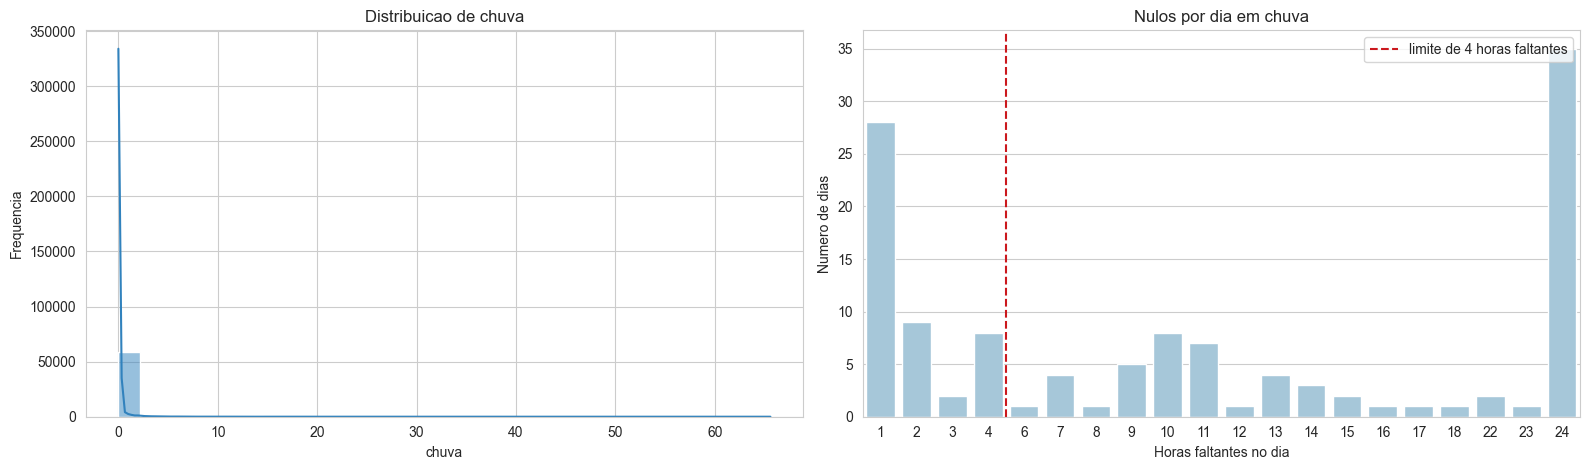

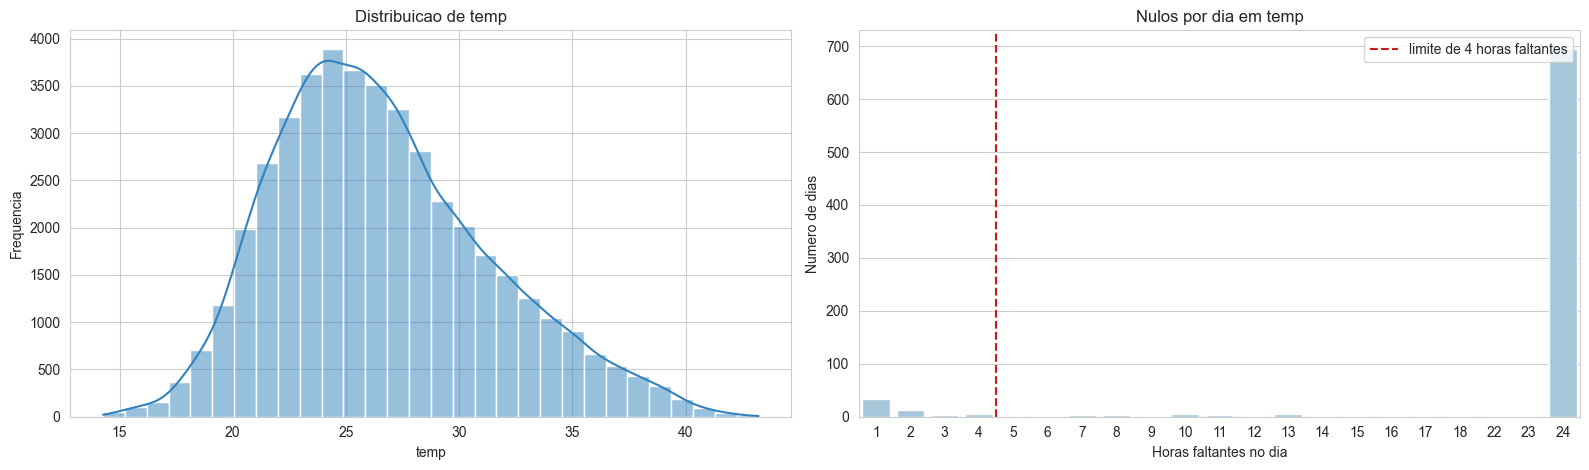

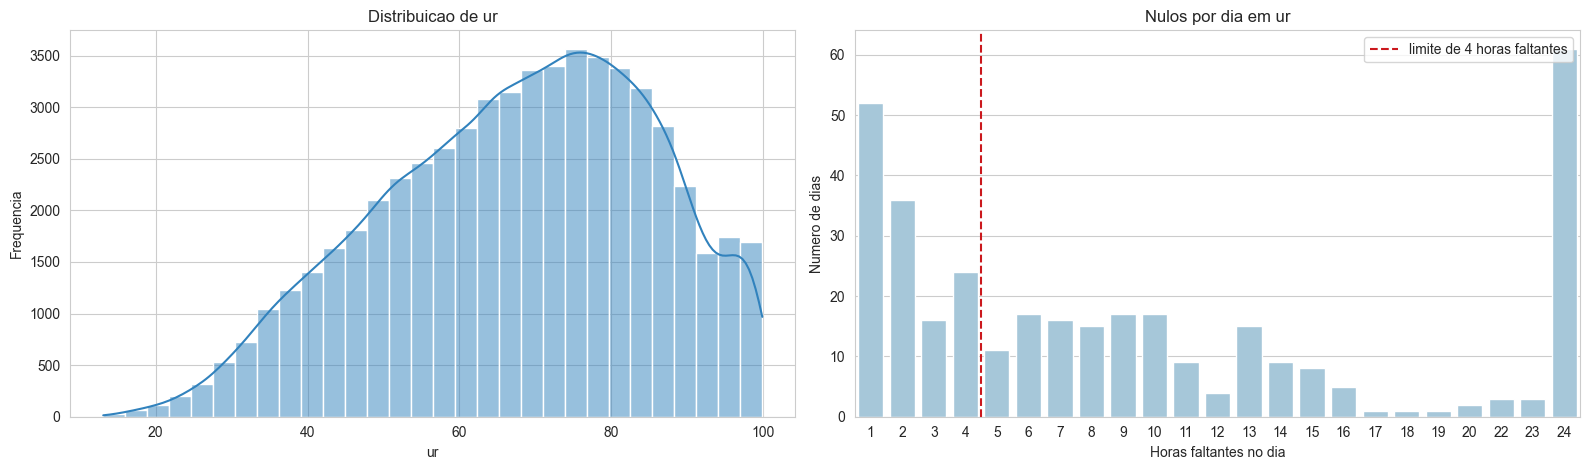

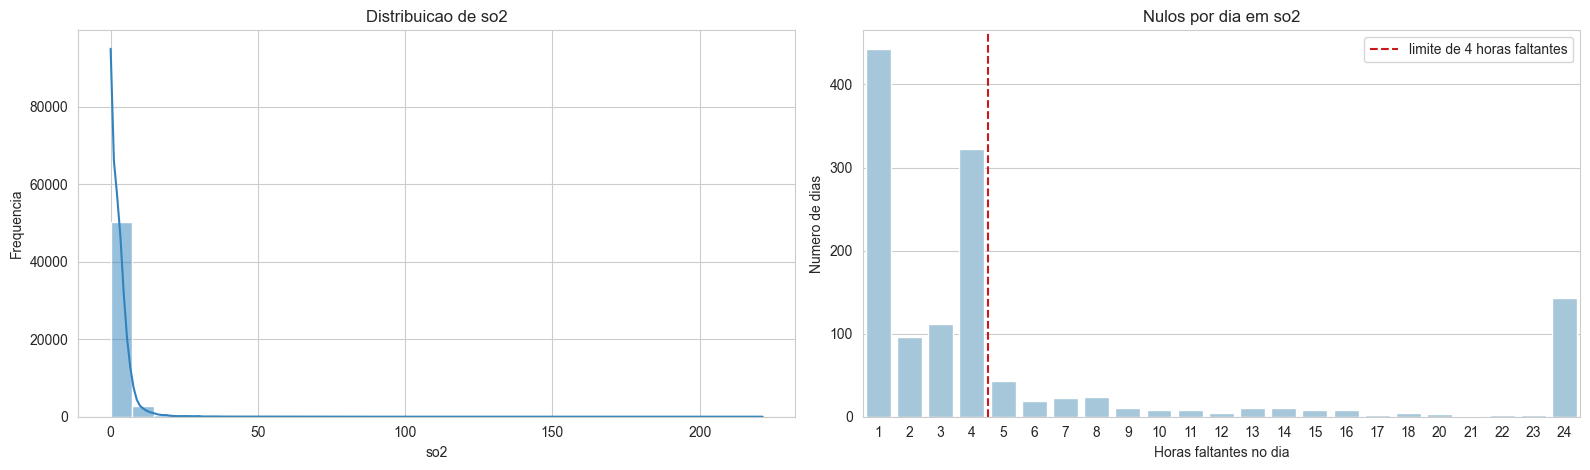

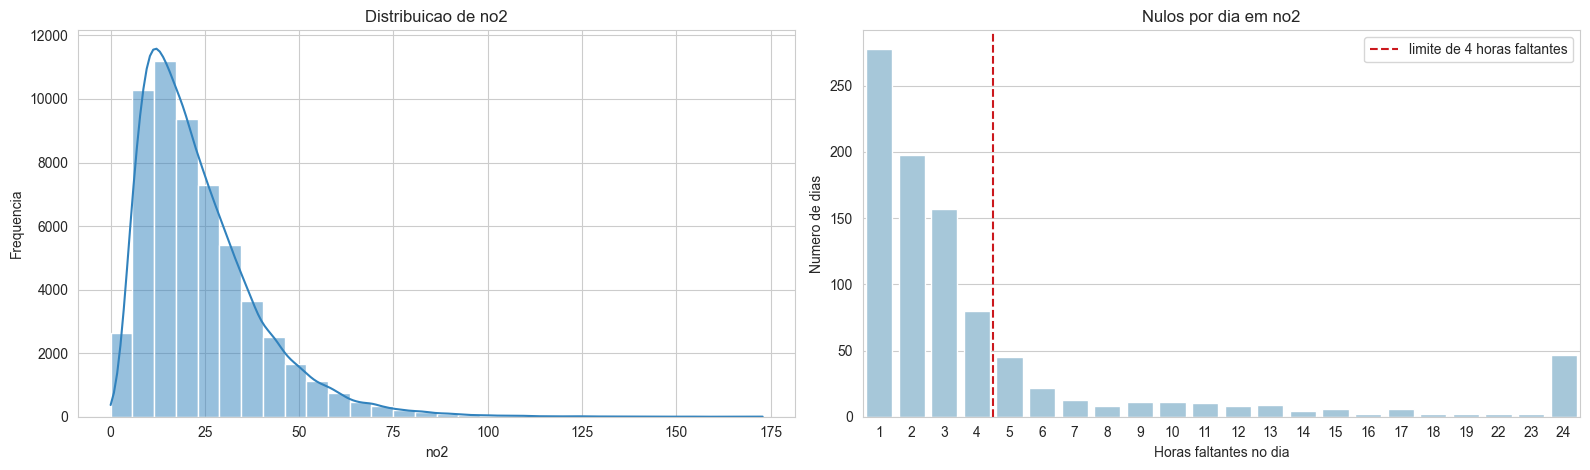

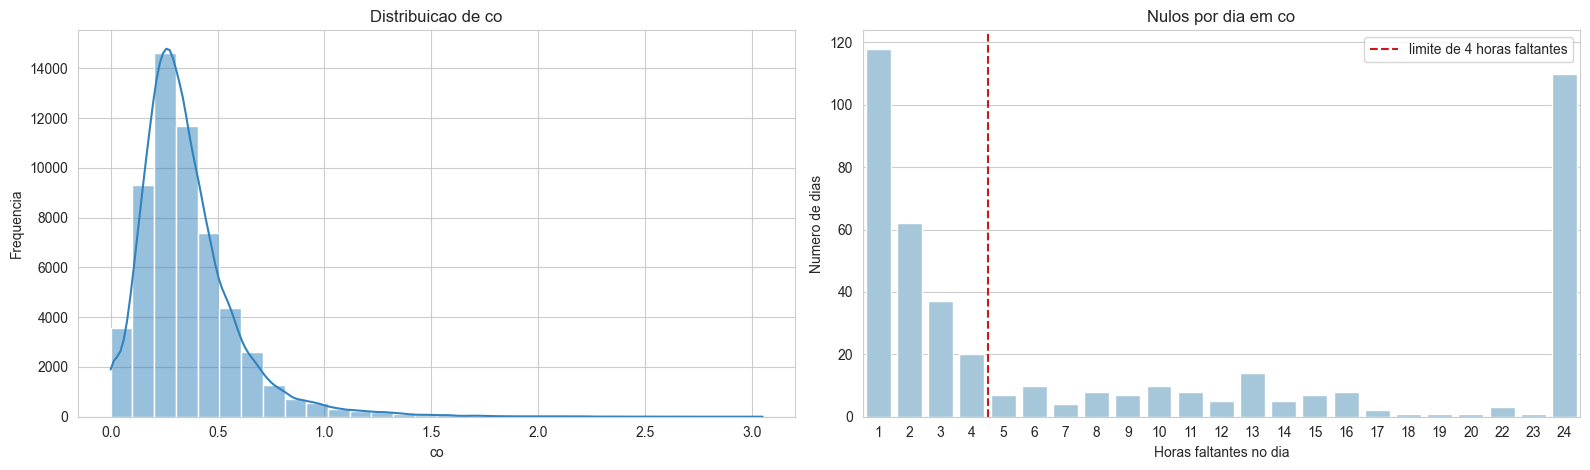

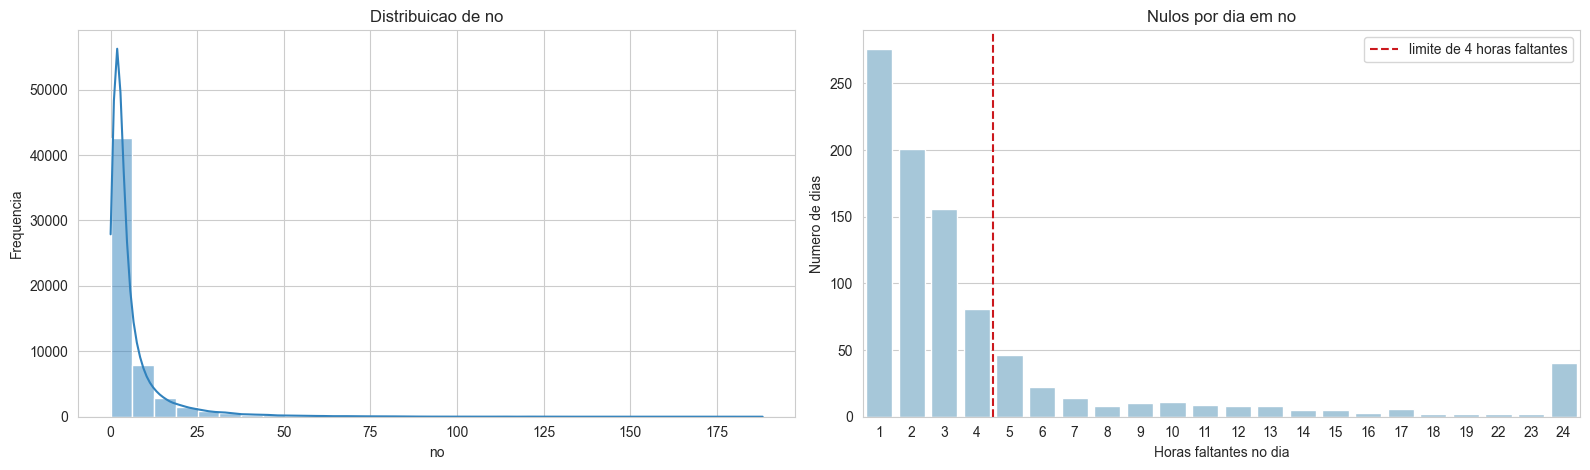

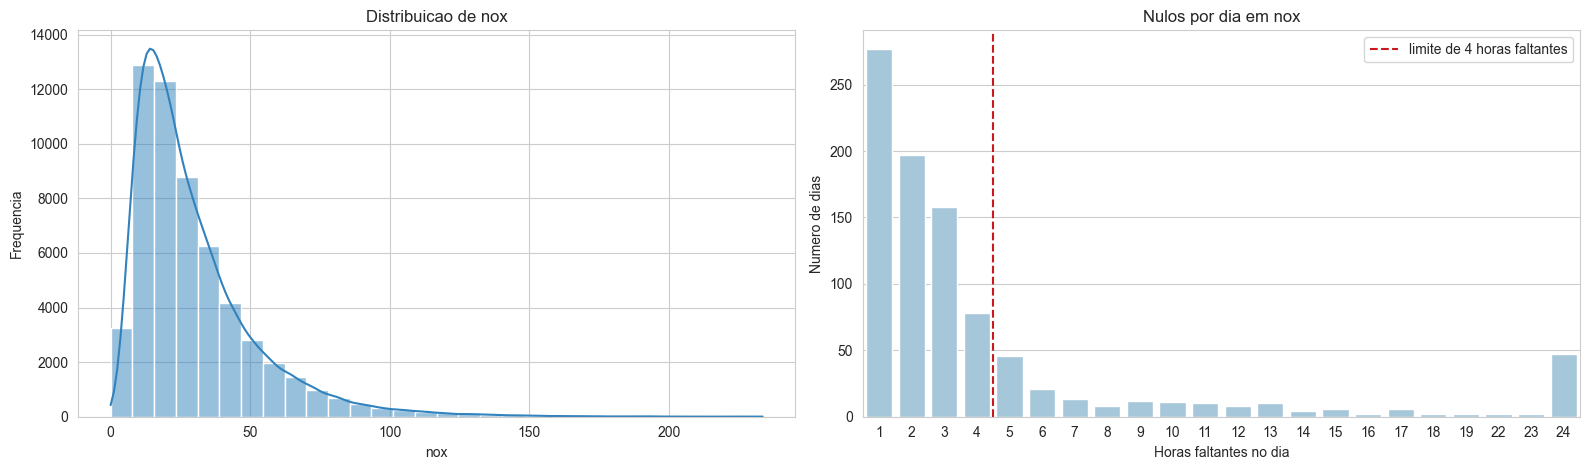

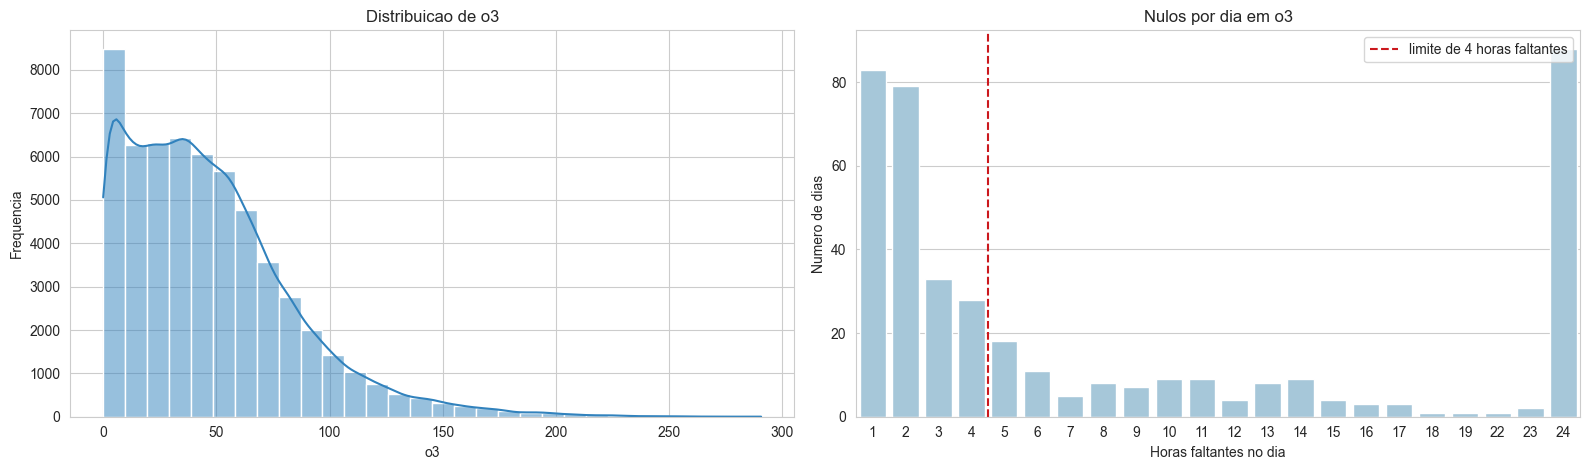

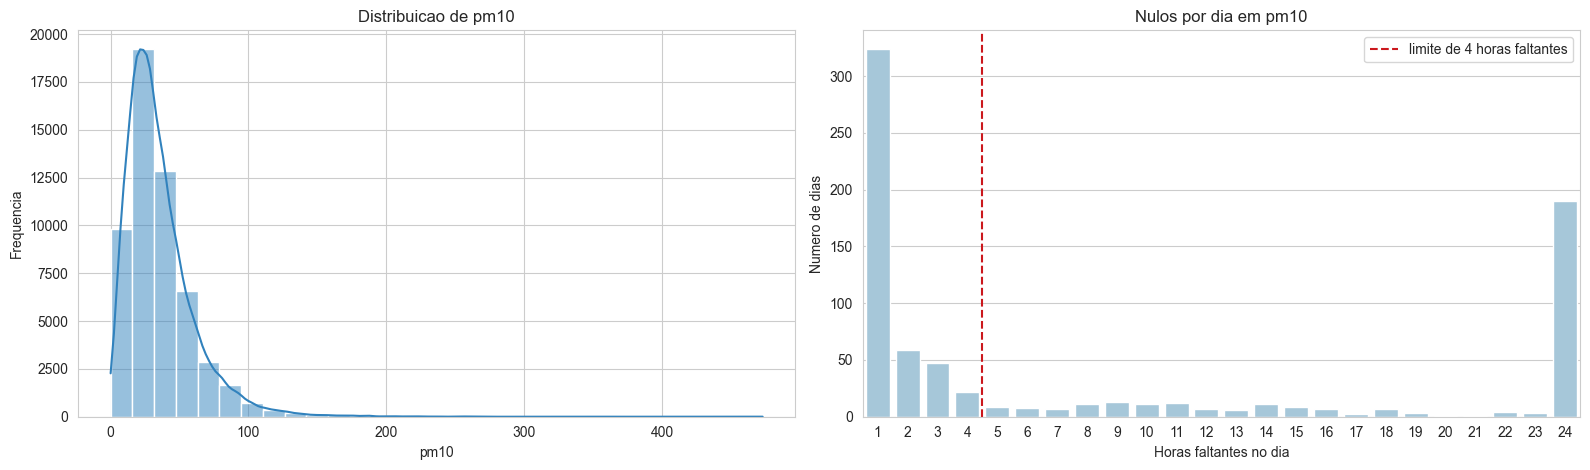

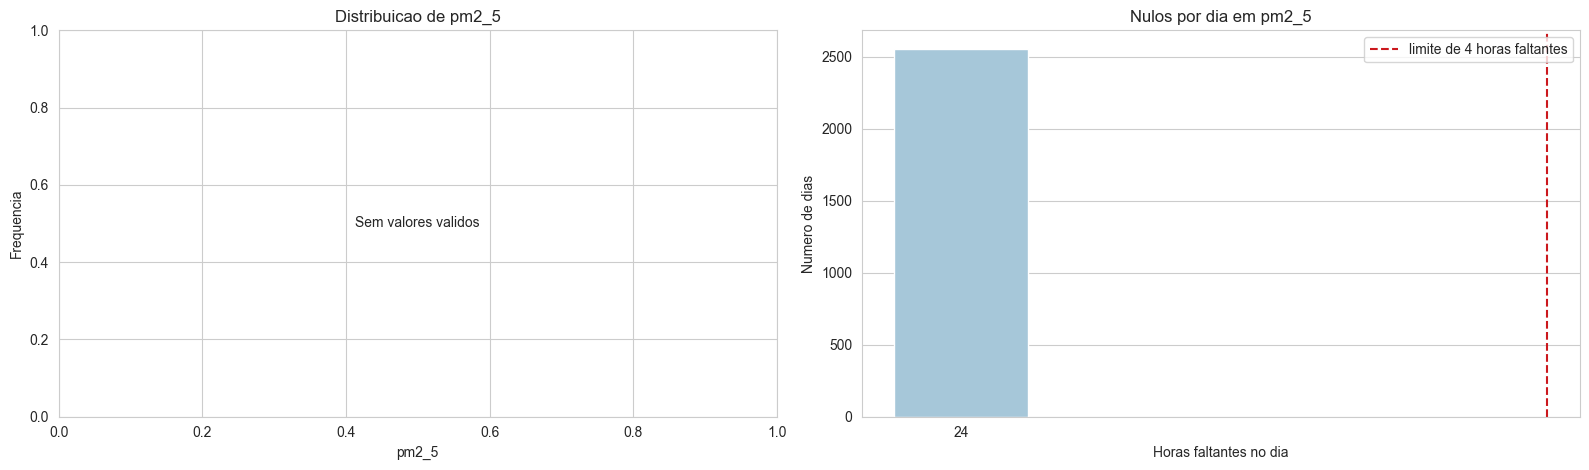

In [14]:
sns.set_style("whitegrid")

for variavel in variaveis_analise:
    serie = df_bangu_carac[variavel].dropna()
    faltantes_por_dia = distribuicoes_missing_diario[variavel]
    distribuicao_faltantes = (
        faltantes_por_dia.value_counts()
        .sort_index()
        .rename_axis("horas_faltantes")
        .reset_index(name="n_dias")
    )
    distribuicao_faltantes = distribuicao_faltantes[distribuicao_faltantes["horas_faltantes"] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

    if not serie.empty:
        sns.histplot(serie, bins=30, kde=True, color="#3182bd", ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, "Sem valores validos", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"Distribuicao de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")

    if not distribuicao_faltantes.empty:
        sns.barplot(data=distribuicao_faltantes, x="horas_faltantes", y="n_dias", color="#9ecae1", ax=axes[1])
        axes[1].axvline(3.5, color="#cb181d", linestyle="--", linewidth=1.5, label="limite de 4 horas faltantes")
        axes[1].legend(loc="upper right")
    else:
        axes[1].text(0.5, 0.5, "Sem dias com horas faltantes", ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Nulos por dia em {variavel}")
    axes[1].set_xlabel("Horas faltantes no dia")
    axes[1].set_ylabel("Numero de dias")

    plt.tight_layout()
    plt.show()

## Resumo interpretativo dos resultados

Os resultados indicam que a estacao de Bangu tem uma base **muito boa do ponto de vista temporal e operacional**, com cobertura continua de `2012-01-01 00:30` a `2018-12-31 23:30`, frequencia horaria regular, ausencia de timestamps faltantes, ausencia de duplicatas de horario e nenhuma evidencia de mudanca de nome ou coordenadas. Isso sugere que, para esta estacao, o principal problema nao esta na linha do tempo da serie, mas sim na completude de algumas variaveis especificas.

A leitura de missing por variavel mostra uma separacao clara de qualidade. `pm2_5` esta totalmente ausente (`100%` de nulos) e, neste recorte, nao deve ser tratada como serie analisavel. `temp` tem perda alta (`28,0%`), enquanto `so2` (`12,2%`) e `pm10` (`11,1%`) tambem exigem mais cautela. Em contrapartida, `chuva`, `ur`, `o3`, `co`, `no`, `no2` e `nox` apresentam cobertura melhor, com missing entre aproximadamente `2%` e `7%`, o que torna essas series mais promissoras para EDA temporal e comparacao entre periodos.

As distribuicoes reforcam que a estacao monitora processos bastante heterogeneos. Entre as variaveis meteorologicas, `chuva` e fortemente concentrada em zero e muito assimetrica, enquanto `temp` e `ur` exibem comportamento mais estavel. Entre os poluentes, todas as series disponiveis mostram **assimetria a direita**, indicando muitos valores usuais e alguns episodios elevados; esse padrao e especialmente forte em `no` e `so2`, enquanto `o3`, `no2`, `nox` e `pm10` combinam nivel central relevante com dispersao ampla. Em termos praticos, isso sugere a presenca de episodios ambientais importantes e indica que medias isoladas podem esconder picos relevantes.

A distribuicao diaria de nulos tambem traz um achado importante para o tratamento futuro. Variaveis como `co`, `o3`, `ur` e `chuva` concentram muitos dias completos e um conjunto nao desprezivel de dias com apenas `1` a `3` horas faltantes, o que sustenta a ideia de imputacao pontual para lacunas curtas. Ja `temp`, `so2` e `pm10` acumulam mais dias com `4` ou mais horas faltantes, entao qualquer estrategia de preenchimento deve ser mais conservadora. Para `pm2_5`, o problema nao e de lacuna curta: a serie esta estruturalmente indisponivel.

Em sintese, a estacao de Bangu parece **confiavel como plataforma de monitoramento**, porque a estrutura temporal da base esta integra e os metadados sao estaveis. O principal cuidado analitico passa a ser tratar cada variavel conforme sua qualidade: `pm2_5` deve ser excluida ou marcada como indisponivel, `temp`, `so2` e `pm10` exigem controle mais rigido de completude, e as demais variaveis podem seguir para as proximas etapas da EDA com boa confianca. Isso deixa claro que, nesta estacao, a confiabilidade e alta no nivel da base, mas desigual no nivel dos sensores e variaveis.